c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0286 - val_loss: 0.0061
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0071 - val_loss: 0.0046
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 0.0037 - val_loss: 0.0049
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0035 - val_loss: 0.0041
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0043 - val_loss: 0.0035
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━

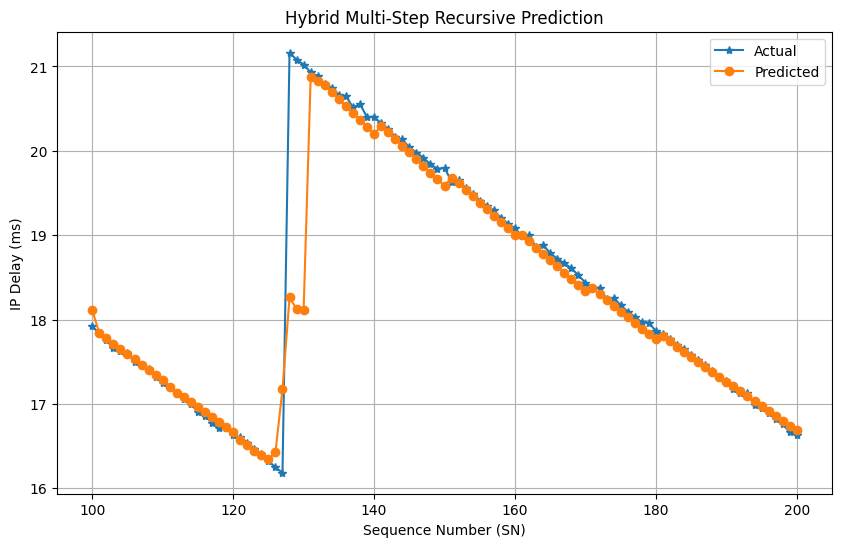

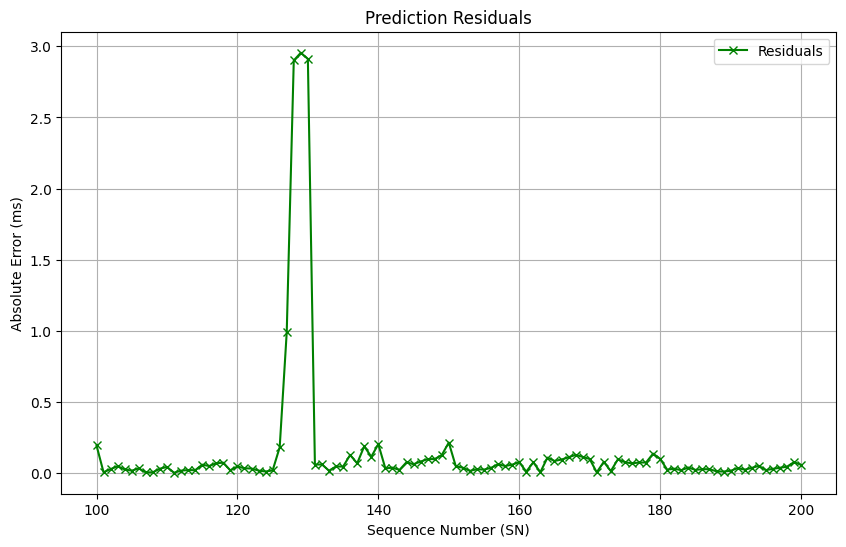

Residual Summary:
 count    3470.000000
mean        0.246035
std         0.708130
min         0.000014
25%         0.025999
50%         0.056611
75%         0.105943
max         4.728184
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0186 - val_loss: 0.0063
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0068 - val_loss: 0.0054
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0061 - val_loss: 0.0049
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0058 - val_loss: 0.0045
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0055 - val_loss: 0.0040
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0044 - val_loss: 0.0048
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0045 - val_loss: 0.0047
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0048 - val_loss: 0.0034
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0040 - val_loss: 0.0046
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - l

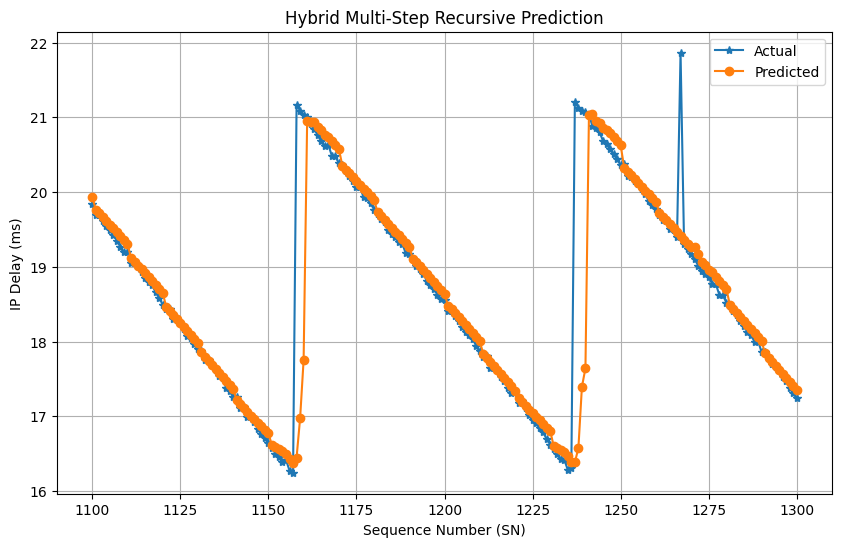

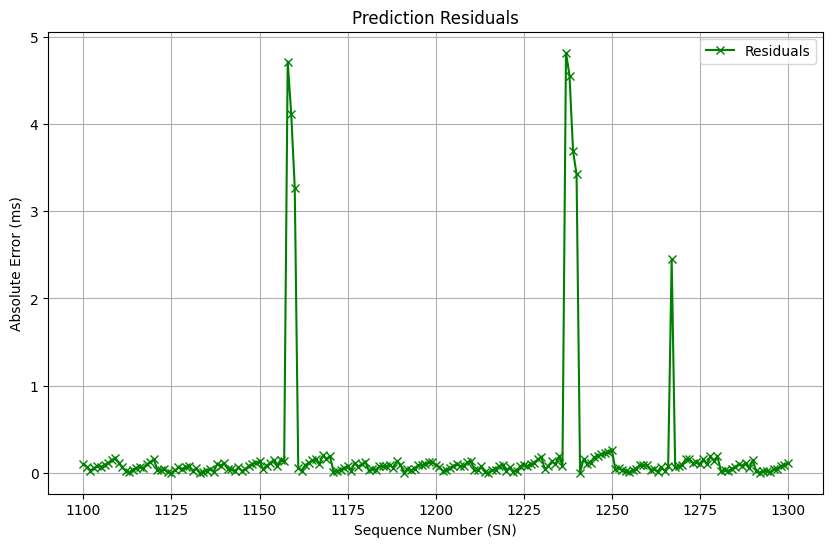

Residual Summary:
 count    3470.000000
mean        0.295252
std         0.856257
min         0.000020
25%         0.039834
50%         0.075536
75%         0.123306
max         4.834607
Name: Absolute Difference (ms), dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 1100) & (result_df['SN'] <= 1300)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('rnn_hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0962 - val_loss: 0.0074
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - val_loss: 0.0086
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0034 - val_loss: 0.0050
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035 - val_loss: 0.0039
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.

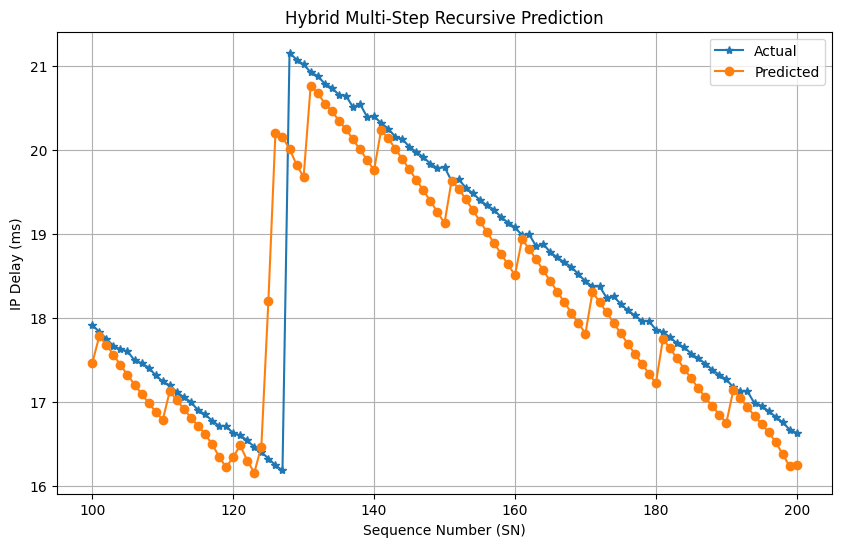

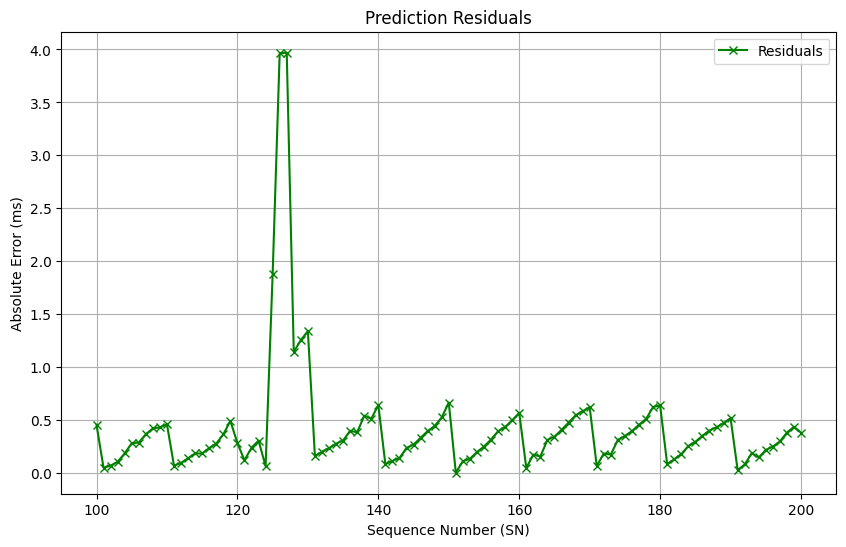

Residual Summary:
 count    3470.000000
mean        0.424714
std         0.533484
min         0.001431
25%         0.172230
50%         0.325929
75%         0.487691
max         4.781287
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Overall Statistics
# -------------------------
mean_absolute_diff = result_df['Absolute Difference (ms)'].mean()
quantile_90_absolute_diff = result_df['Absolute Difference (ms)'].quantile(0.90)
variance_absolute_diff = result_df['Absolute Difference (ms)'].var()

# Store each statistic in a separate CSV file
mean_df = pd.DataFrame({'Metric': ['Mean Absolute Difference (ms)'], 'Value': [mean_absolute_diff]})
mean_df.to_csv('mean_hybrid_rnn.csv', index=False)

quantile_df = pd.DataFrame({'Metric': ['90th Quantile Absolute Difference (ms)'], 'Value': [quantile_90_absolute_diff]})
quantile_df.to_csv('90thquantile_hybrid_rnn.csv', index=False)

variance_df = pd.DataFrame({'Metric': ['Variance Absolute Difference (ms²)'], 'Value': [variance_absolute_diff]})
variance_df.to_csv('variance_hybrid_rnn.csv', index=False)

print("Overall Prediction Statistics:")
print("Mean Absolute Difference:\n", mean_df)
print("90th Quantile Absolute Difference:\n", quantile_df)
print("Variance Absolute Difference:\n", variance_df)

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)

print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0717 - val_loss: 0.0132
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0130 - val_loss: 0.0096
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079 - val_loss: 0.0063
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0054
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0053 - val_loss: 0.0049
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 0.0051
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - val_loss: 0.0058
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 - val_loss: 0.0056
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - val_loss: 0.0050
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - val_loss: 0.0065
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0063 - val_loss: 0.0045


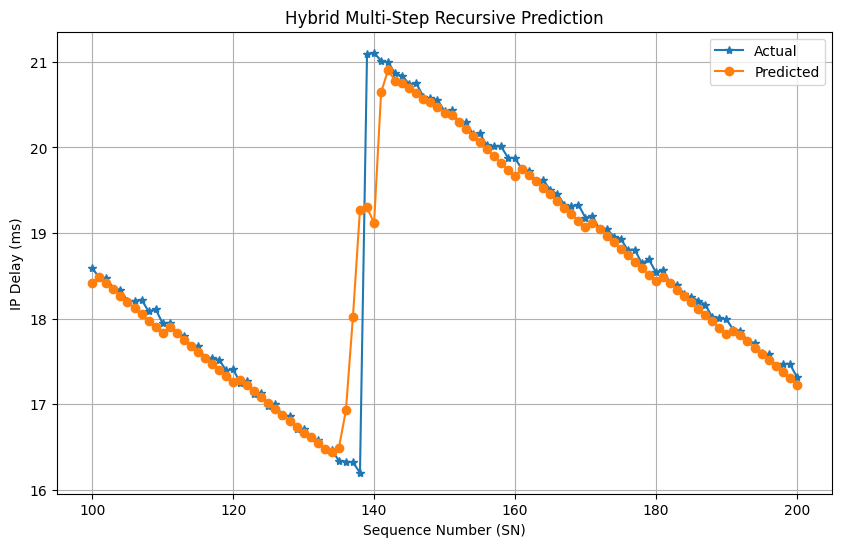

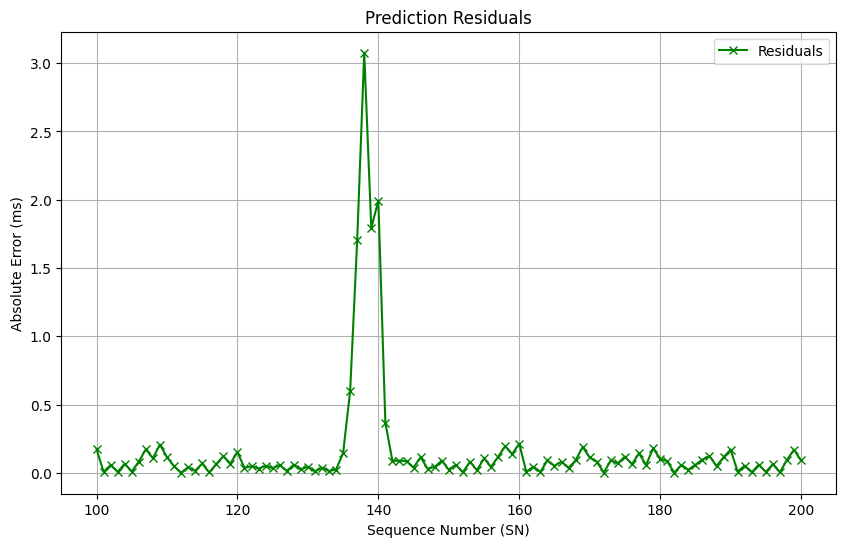

Residual Summary:
 count    8970.000000
mean        0.218529
std         0.491296
min         0.000045
25%         0.037319
50%         0.075375
75%         0.126640
max         4.612551
Name: Absolute Difference (ms), dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Statistics for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(result_df) // range_size  # Adjusted to match prediction length
range_starts = [i * range_size + 1 for i in range(num_ranges)]
range_ends = [(i + 1) * range_size for i in range(num_ranges)]

mean_absolute_diff_range = []
quantile_90_absolute_diff_range = []
variance_absolute_diff_range = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        mean_absolute_diff_range.append(range_df['Absolute Difference (ms)'].mean())
        quantile_90_absolute_diff_range.append(range_df['Absolute Difference (ms)'].quantile(0.90))
        variance_absolute_diff_range.append(range_df['Absolute Difference (ms)'].var())

# Store each statistic in a separate CSV file
mean_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Mean Absolute Difference (ms)': mean_absolute_diff_range
})
mean_df.to_csv('mean_hybrid_rnn_range.csv', index=False)

quantile_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    '90th Quantile Absolute Difference (ms)': quantile_90_absolute_diff_range
})
quantile_df.to_csv('90thquantile_hybrid_rnn_range.csv', index=False)

variance_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Variance Absolute Difference (ms²)': variance_absolute_diff_range
})
variance_df.to_csv('variance_hybrid_rnn_range.csv', index=False)

print("Range-Based Prediction Statistics:")
print("Mean Absolute Difference:\n", mean_df)
print("90th Quantile Absolute Difference:\n", quantile_df)
print("Variance Absolute Difference:\n", variance_df)

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)

print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())